In [43]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Import necessary libraries for model building and evaluation
from sklearn.model_selection import train_test_split # For splitting data into training and testing sets
from sklearn.preprocessing import StandardScaler,LabelEncoder # For feature scaling and encoding categorical features
from sklearn.ensemble import RandomForestClassifier # The chosen classification model
from sklearn.metrics import classification_report,confusion_matrix,accuracy_score # For evaluating model performance

In [44]:
# Load the dataset from a CSV file into a pandas DataFrame
df = pd.read_csv('/content/Churn_Modelling.csv')

In [45]:
# Display the first 5 rows of the DataFrame to get a quick overview of the data
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [46]:
# Display concise summary of the DataFrame, including data types and non-null values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [47]:
# Check for missing values in each column and sum them up
df.isnull().sum()

,0
RowNumber,0
CustomerId,0
Surname,0
CreditScore,0
Geography,0
Gender,0
Age,0
Tenure,0
Balance,0
NumOfProducts,0


In [48]:
# Check for duplicate rows in the DataFrame
df.duplicated().sum()

np.int64(0)

In [49]:
# Initialize LabelEncoder for categorical features
label_encoder = LabelEncoder()
# Encode 'Gender' column from categorical (Male/Female) to numerical (0/1)
df['Gender'] = label_encoder.fit_transform(df['Gender'])
# Apply one-hot encoding to 'Geography' column. `drop_first=True` avoids multicollinearity.
df = pd.get_dummies(df, columns=['Geography'], drop_first=True)

In [50]:
# Display the first 5 rows of the DataFrame after preprocessing 'Gender' and 'Geography'
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain
0,1,15634602,Hargrave,619,0,42,2,0.00,1,1,1,101348.88,1,False,False
1,2,15647311,Hill,608,0,41,1,83807.86,1,0,1,112542.58,0,False,True
2,3,15619304,Onio,502,0,42,8,159660.80,3,1,0,113931.57,1,False,False
3,4,15701354,Boni,699,0,39,1,0.00,2,0,0,93826.63,0,False,False
4,5,15737888,Mitchell,850,0,43,2,125510.82,1,1,1,79084.10,0,False,True


In [51]:
# Define the features (independent variables) to be used for training the model
features = ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember',
            'EstimatedSalary', 'Gender', 'Geography_Spain','Geography_Germany']
# Create the feature matrix 'x'
x = df[features]
# Create the target vector 'y' (the 'Exited' column indicating churn)
y= df['Exited']

In [52]:
# Split the dataset into training and testing sets
# 80% of data for training (x_train, y_train) and 20% for testing (x_test, y_test)
# random_state ensures reproducibility of the split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [53]:
# Initialize the StandardScaler for feature scaling
scaler = StandardScaler()
# Fit the scaler on the training data and transform both training and testing data
# Scaling standardizes features by removing the mean and scaling to unit variance
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

In [68]:
import joblib

# Define the filename for your scaler
scaler_filename = 'scaler.joblib'

# Save the scaler to the file
joblib.dump(scaler, scaler_filename)

print(f"Scaler saved to {scaler_filename}")

Scaler saved to scaler.joblib


```markdown
Now that the scaler has been saved, please make sure to **download both `random_forest_model.joblib` and `scaler.joblib`** from your Colab environment and place them in the same directory as your `streamlit_app.py` file on your local machine.

Then, try running your Streamlit application again: `streamlit run streamlit_app.py`
```

In [ ]:
import joblib

# Define the filename for your scaler
scaler_filename = 'scaler.joblib'

# Save the scaler to the file
joblib.dump(scaler, scaler_filename)

print(f"Scaler saved to {scaler_filename}")

In [54]:
# Initialize a RandomForestClassifier model with 100 estimators and a fixed random state
model = RandomForestClassifier(n_estimators=100, random_state=42)
# Train the Random Forest model using the scaled training data
model.fit(x_train,y_train)

RandomForestClassifier(random_state=42)

In [55]:
# Make predictions on the scaled test data using the trained Random Forest model
y_pred = model.predict(x_test)

In [56]:
# Calculate the confusion matrix to evaluate classification performance
conf_matrix = confusion_matrix(y_test,y_pred)
# Calculate the accuracy score of the model
accuracy = accuracy_score(y_test,y_pred)
# Generate a classification report, including precision, recall, and f1-score
class_report = classification_report(y_test,y_pred)

# Print the evaluation metrics
print("Confusion Matrix:")
print(conf_matrix)
print("\nAccuracy:", accuracy)
print("\nClassification Report:")
print(class_report)

Confusion Matrix:
[[1554   53]
 [ 208  185]]

Accuracy: 0.8695

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.97      0.92      1607
           1       0.78      0.47      0.59       393

    accuracy                           0.87      2000
   macro avg       0.83      0.72      0.75      2000
weighted avg       0.86      0.87      0.86      2000



              Feature  Importance
1                 Age    0.236316
7     EstimatedSalary    0.146238
0         CreditScore    0.142249
3             Balance    0.141559
4       NumOfProducts    0.133066
2              Tenure    0.082248
6      IsActiveMember    0.040836
10  Geography_Germany    0.025867
8              Gender    0.019471
5           HasCrCard    0.018871
9     Geography_Spain    0.013279


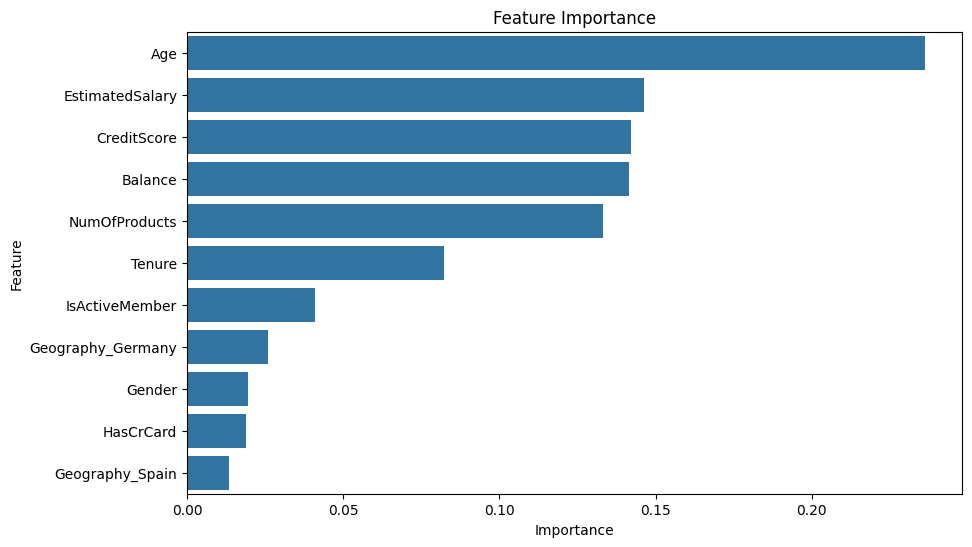

In [57]:
importances = model.feature_importances_
feature_importances = pd.DataFrame({'Feature': features, 'Importance': importances})
feature_importances = feature_importances.sort_values(by='Importance', ascending=False)
print(feature_importances)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importances)
plt.title('Feature Importance')
plt.show()

In [58]:
from sklearn.linear_model import LogisticRegression

# build and train logistic regression model
model_logistic = LogisticRegression()
model_logistic.fit(x_train,y_train)

# make predictions
y_pred_logistic = model_logistic.predict(x_test)

# evaluate the model
conf_matrix_logistic = confusion_matrix(y_test,y_pred_logistic)
accuracy_logistic = accuracy_score(y_test,y_pred_logistic)
class_report_logistic = classification_report(y_test,y_pred_logistic)

print("Confusion Matrix (Logistic Regression):")
print(conf_matrix_logistic)
print("\nAccuracy (Logistic Regression):", accuracy_logistic)
print("\nClassification Report (Logistic Regression):")
print(class_report_logistic)

Confusion Matrix (Logistic Regression):
[[1543   64]
 [ 314   79]]

Accuracy (Logistic Regression): 0.811

Classification Report (Logistic Regression):
              precision    recall  f1-score   support

           0       0.83      0.96      0.89      1607
           1       0.55      0.20      0.29       393

    accuracy                           0.81      2000
   macro avg       0.69      0.58      0.59      2000
weighted avg       0.78      0.81      0.77      2000



In [59]:
from sklearn.svm import SVC

# build and train SVM model
model_svm = SVC()
model_svm.fit(x_train,y_train)

# make predictions
y_pred_svm = model_svm.predict(x_test)

# evaluate the model
conf_matrix_svm = confusion_matrix(y_test,y_pred_svm)
accuracy_svm = accuracy_score(y_test,y_pred_svm)
class_report_svm = classification_report(y_test,y_pred_svm)

print("Confusion Matrix (SVM):")
print(conf_matrix_svm)
print("\nAccuracy (SVM):", accuracy_svm)
print("\nClassification Report (SVM):")
print(class_report_svm)

Confusion Matrix (SVM):
[[1562   45]
 [ 243  150]]

Accuracy (SVM): 0.856

Classification Report (SVM):
              precision    recall  f1-score   support

           0       0.87      0.97      0.92      1607
           1       0.77      0.38      0.51       393

    accuracy                           0.86      2000
   macro avg       0.82      0.68      0.71      2000
weighted avg       0.85      0.86      0.84      2000



In [60]:
from sklearn.neighbors import KNeighborsClassifier

# build and train KNN model
model_knn = KNeighborsClassifier()
model_knn.fit(x_train,y_train)

# make predictions
y_pred_knn = model_knn.predict(x_test)

# evaluate the model
conf_matrix_knn = confusion_matrix(y_test,y_pred_knn)
accuracy_knn = accuracy_score(y_test,y_pred_knn)
class_report_knn = classification_report(y_test,y_pred_knn)

print("Confusion Matrix (KNN):")
print(conf_matrix_knn)
print("\nAccuracy (KNN):", accuracy_knn)
print("\nClassification Report (KNN):")
print(class_report_knn)

Confusion Matrix (KNN):
[[1514   93]
 [ 247  146]]

Accuracy (KNN): 0.83

Classification Report (KNN):
              precision    recall  f1-score   support

           0       0.86      0.94      0.90      1607
           1       0.61      0.37      0.46       393

    accuracy                           0.83      2000
   macro avg       0.74      0.66      0.68      2000
weighted avg       0.81      0.83      0.81      2000



In [61]:
# Display the first few rows of the DataFrame to verify the previous changes
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain
0,1,15634602,Hargrave,619,0,42,2,0.00,1,1,1,101348.88,1,False,False
1,2,15647311,Hill,608,0,41,1,83807.86,1,0,1,112542.58,0,False,True
2,3,15619304,Onio,502,0,42,8,159660.80,3,1,0,113931.57,1,False,False
3,4,15701354,Boni,699,0,39,1,0.00,2,0,0,93826.63,0,False,False
4,5,15737888,Mitchell,850,0,43,2,125510.82,1,1,1,79084.10,0,False,True


In [62]:
# Reload the original dataset to perform feature engineering from scratch
df = pd.read_csv('/content/Churn_Modelling.csv')

# Create a binary feature: 1 if Balance is zero, 0 otherwise
df['Balance_zero'] = (df['Balance'] == 0).astype(int)

# Create age groups (bins) for the 'Age' column
df['Age_Group'] = pd.cut(df['Age'], bins=[18,25,35,45,55,65,75,85,95],
                         labels=['18-25','26-35','36-45','46-55','56-65','66-75','76-85','86-95'])

# Calculate the ratio of Balance to EstimatedSalary
df['balance_to_salary_ratio'] = df['Balance'] / df['EstimatedSalary']

# Create an interaction feature between 'NumOfProducts' and 'IsActiveMember'
df['Product_usage'] = df['NumOfProducts'] * df['IsActiveMember']

# Create tenure groups (bins) for the 'Tenure' column
df['Tenure_Group'] = pd.cut(df['Tenure'], bins=[0,2,5,7,10], labels=['0-2','3-5','6-7','8-10'])

In [63]:
# Initialize LabelEncoder for categorical features (Gender)
label_encoder = LabelEncoder()
# Encode 'Gender' column from categorical (Male/Female) to numerical (0/1)
df['Gender'] = label_encoder.fit_transform(df['Gender'])
# Apply one-hot encoding to 'Geography' column. `drop_first=True` avoids multicollinearity.
df = pd.get_dummies(df, columns=['Geography'], drop_first=True)
# Create interaction features between 'Gender' (Male) and 'Geography' (Germany, Spain)
df['Male_Germany'] = df['Gender'] * df['Geography_Germany']
df['Male_Spain'] = df['Gender'] * df['Geography_Spain']
# Apply one-hot encoding to the newly created 'Age_Group' and 'Tenure_Group' columns
df = pd.get_dummies(df, columns=['Age_Group','Tenure_Group'], drop_first=True)

In [64]:
# Update the features list with the newly engineered features
features = ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember',
            'EstimatedSalary', 'Gender', 'Geography_Spain', 'Geography_Germany',
            'Balance_zero', 'balance_to_salary_ratio', 'Product_usage',
            'Male_Germany', 'Male_Spain',
            'Age_Group_26-35', 'Age_Group_36-45', 'Age_Group_46-55', 'Age_Group_56-65',
            'Age_Group_66-75', 'Age_Group_76-85', 'Age_Group_86-95',
            'Tenure_Group_3-5', 'Tenure_Group_6-7', 'Tenure_Group_8-10']
x = df[features]
y= df['Exited']

# Re-split the data into training and testing sets with the updated features
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

# Re-initialize and re-scale the features using StandardScaler
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

In [65]:
# Initialize a RandomForestClassifier model with 100 estimators and a fixed random state
model = RandomForestClassifier(n_estimators=100, random_state=42)
# Train the Random Forest model using the scaled training data
model.fit(x_train,y_train)

# Make predictions on the scaled test data
y_pred = model.predict(x_test)

# Calculate and print the accuracy score of the model
accuracy = accuracy_score(y_test,y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.866


In [66]:
import joblib

# Define the filename for your trained model
model_filename = 'random_forest_model.joblib'

# Save the model to the file using joblib
joblib.dump(model, model_filename)

print(f"Model saved to {model_filename}")

Model saved to random_forest_model.joblib


In [67]:
import joblib
# To load the model back later from the saved file
loaded_model = joblib.load('random_forest_model.joblib')
print("Model loaded successfully!")

# You can then use loaded_model for predictions
# For example:
# new_predictions = loaded_model.predict(new_data)

Model loaded successfully!
